# Regime visualization & diagnostic sanity panel — CAI-JEPA

Visualizes **frames + state** at each of the four manipulation regimes
(`free_space`, `pre_grasp`, `gripper_actuation`, `contact_manipulation`) on the
**Metaworld** primary diagnostic, plus a set of supporting plots that make the
action-grounding gap (and how the regimes are defined) visible.

**What this notebook does**
1. Loads the latent cache (`data/precomputed_latents/metaworld__*.h5`) + the
   regime sidecar produced by `04_classify_regimes.py`.
2. Builds a per-transition table with the state features the proxy stratifier
   uses (object displacement, ee↔object distance, gripper Δ) and the latent
   change ‖Δz‖.
3. Decodes the raw RGB frames **directly from the HF parquet** (bypassing
   `torchcodec`, which needs FFmpeg DLLs absent on this box) and shows a gallery
   per regime, with an alignment check against the cached `state`.
4. Supporting viz: regime distribution, state-space separability, ‖Δz‖
   histograms, per-task regime composition, the CRA gap by strategy×regime, and
   Boundary-Blindness by regime — all read from the existing result CSVs.

> Frames are **Metaworld-only** here (data + a bundled FFmpeg are local). DROID
> frames need the server; its CSV-based plots are still included below.


## 0 · Setup

In [1]:
import sys, json, functools, glob
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25

# Locate the diagnosis/ root regardless of where Jupyter was launched.
def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "precomputed_latents").is_dir() and (p / "stratification").is_dir():
            return p
    raise FileNotFoundError("Could not locate the diagnosis/ root (data/precomputed_latents).")

ROOT = find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
print("diagnosis root:", ROOT)

# ---- pick which model's cache to visualize -------------------------------
DATASET = "metaworld"
MODEL = "dino_wm_metaworld"   # or "jepa_wm_metaworld"
CACHE = ROOT / "data" / "precomputed_latents" / f"{DATASET}__{MODEL}.h5"
SIDECAR = CACHE.with_name(CACHE.name + ".regimes.json")
PARQUET_DIR = ROOT / "data" / "hf_mw" / "metaworld" / "data"
RESULTS = ROOT / "results"
assert CACHE.exists(), f"missing cache {CACHE} — run 03_extract_latents.py"
assert SIDECAR.exists(), f"missing regimes {SIDECAR} — run 04_classify_regimes.py"

REGIMES = ["free_space", "pre_grasp", "gripper_actuation", "contact_manipulation"]
REGIME_COLORS = {
    "free_space": "#4C72B0", "pre_grasp": "#DD8452",
    "gripper_actuation": "#55A868", "contact_manipulation": "#C44E52",
}
ID_TO_REGIME = {0: "free_space", 1: "pre_grasp", 2: "gripper_actuation", 3: "contact_manipulation"}

# Metaworld 39-dim state layout (see stratification/metaworld_regimes.py)
EE = slice(0, 3); GRIP = 3; OBJ = slice(4, 7)
print("model:", MODEL)

diagnosis root: e:\code-project\jepa-research\diagnosis
model: dino_wm_metaworld


## 1 · Per-transition table (state features + ‖Δz‖)

One row per transition `(traj_id, t)`: the regime label from the sidecar plus
the exact quantities the Metaworld proxy uses to assign it — object
displacement (contact proxy), ee↔object distance (pre-grasp proxy), gripper Δ —
and the model's latent change ‖z_{t+1}−z_t‖.

In [2]:
regimes = {k: np.asarray(v, dtype=np.int8) for k, v in json.load(open(SIDECAR)).items()}

rows = []
with h5py.File(CACHE, "r") as h:
    grp = h["trajectories"]
    for key in grp.keys():
        g = grp[key]
        tid = g.attrs.get("traj_id", key)
        task = tid.split("/")[0]
        z = g["z"][:]                                  # (T, V, Hs, Ws, D)
        state = g["state"][:]                          # (T, 39)
        reg = regimes.get(tid)
        if reg is None:
            continue
        zf = z.reshape(z.shape[0], -1)                 # flatten patch latent
        T = len(reg)
        for t in range(T):
            obj_disp = float(np.linalg.norm(state[t + 1][OBJ] - state[t][OBJ]))
            ee_obj   = float(np.linalg.norm(state[t][EE] - state[t][OBJ]))
            grip_d   = float(abs(state[t + 1][GRIP] - state[t][GRIP]))
            dz       = float(np.linalg.norm(zf[t + 1] - zf[t]))
            rows.append(dict(traj_id=tid, task=task, t=t,
                             regime=ID_TO_REGIME[int(reg[t])],
                             obj_disp=obj_disp, ee_obj=ee_obj,
                             grip_delta=grip_d, dz=dz))
df = pd.DataFrame(rows)
print(f"{len(df):,} transitions across {df.traj_id.nunique()} trajectories, {df.task.nunique()} tasks")
df.head()

70,560 transitions across 720 trajectories, 12 tasks


,traj_id,task,t,regime,obj_disp,ee_obj,grip_delta,dz
0,mw-assembly/00000,mw-assembly,0,free_space,0.001127,0.213640,0.000000,77.823738
1,mw-assembly/00000,mw-assembly,1,free_space,0.000072,0.212142,0.000000,85.824059
2,mw-assembly/00000,mw-assembly,2,free_space,0.000231,0.207456,0.000400,96.339218
3,mw-assembly/00000,mw-assembly,3,free_space,0.000174,0.200360,0.011410,120.730934
4,mw-assembly/00000,mw-assembly,4,free_space,0.000109,0.191478,0.020534,124.086990


## 2 · Regime distribution

,n_transitions,pct
regime,,
free_space,22708,32.2
pre_grasp,28482,40.4
gripper_actuation,0,0.0
contact_manipulation,19370,27.5


C:\Users\Admin\AppData\Local\Temp\ipykernel_34768\1882728066.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=20, ha="right")


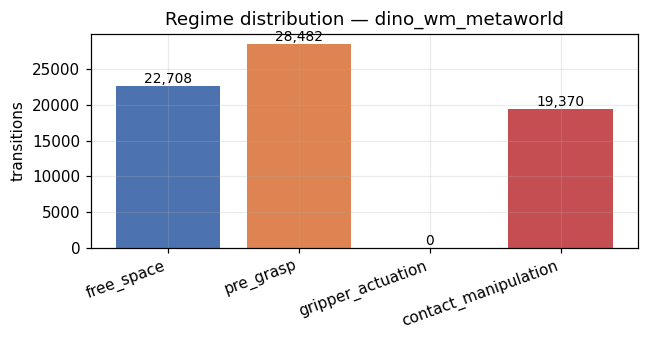

NOTE: gripper_actuation is empty on Metaworld — expected (the HF release has no usable gripper-actuation signal; DROID fills it).


In [3]:
counts = df.regime.value_counts().reindex(REGIMES).fillna(0).astype(int)
display(counts.to_frame("n_transitions").assign(
    pct=(100 * counts / counts.sum()).round(1)))

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(counts.index, counts.values, color=[REGIME_COLORS[r] for r in counts.index])
ax.set_ylabel("transitions"); ax.set_title(f"Regime distribution — {MODEL}")
ax.set_xticklabels(counts.index, rotation=20, ha="right")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

if counts.get("gripper_actuation", 0) == 0:
    print("NOTE: gripper_actuation is empty on Metaworld — expected (the HF "
          "release has no usable gripper-actuation signal; DROID fills it).")

## 3 · Raw-frame loader (parquet → RGB, with alignment check)

`MetaworldHFDataset` decodes the per-episode MP4 via `torchcodec`, which fails
to load on this box (missing FFmpeg DLLs). We replicate the loader's
`traj_id → (parquet row)` mapping — **sorted parquet files, filter by task
preserving order, first `cap` rows per task** — and decode the MP4 bytes with
`imageio` (FFmpeg bundled via `imageio-ffmpeg`). Each decode is verified against
the cached `state` so a wrong mapping can't pass silently.

In [4]:
import io, yaml, imageio

# cap per task = max_trajectories_per_task used when the cache was built
try:
    cfg = yaml.safe_load(open(ROOT / "configs" / "diagnostic_metaworld.yaml"))
    CAP = int(cfg["dataset"].get("max_trajectories_per_task", 60))
except Exception:
    CAP = 60

@functools.lru_cache(maxsize=1)
def _build_index():
    # traj_id -> (parquet_file, local_row_index), replicating HF concat order
    files = sorted(glob.glob(str(PARQUET_DIR / "train-*.parquet")))
    import pyarrow.parquet as pq
    counts, index = {}, {}
    for f in files:
        tasks = pq.read_table(f, columns=["task"])["task"].to_pylist()
        for j, tk in enumerate(tasks):
            c = counts.get(tk, 0)
            if c >= CAP:
                continue
            index[f"{tk}/{c:05d}"] = (f, j)
            counts[tk] = c + 1
    return index

@functools.lru_cache(maxsize=64)
def load_frames(traj_id: str) -> np.ndarray:
    # Decode the episode's frames (T, H, W, 3) uint8, aligned to cached transitions
    import pyarrow.parquet as pq
    f, j = _build_index()[traj_id]
    tbl = pq.read_table(f, columns=["video", "states"])
    vid = tbl["video"][j].as_py()
    vb = vid["bytes"] if isinstance(vid, dict) else vid
    rdr = imageio.get_reader(io.BytesIO(vb), format="mp4")
    frames = np.stack([fr for fr in rdr]); rdr.close()
    # alignment check vs cached state
    pq_states = np.asarray(tbl["states"][j].as_py(), dtype=np.float32)
    with h5py.File(CACHE, "r") as h:
        cst = h["trajectories"][traj_id.replace("/", "--SLASH--")]["state"][:]
    n = cst.shape[0]
    if not np.allclose(cst, pq_states[:n], atol=1e-3):
        raise AssertionError(f"frame/state misalignment for {traj_id}")
    return frames[:n + 1]            # need frame[t] and frame[t+1]

# smoke test
_t0 = df.traj_id.iloc[0]
print("index size:", len(_build_index()), "| sample frames:", load_frames(_t0).shape)

index size: 2520 | sample frames: (100, 224, 224, 3)


## 4 · Regime gallery — what each regime *looks like*

For every (non-empty) regime, a random sample of transitions; each tile is
`frame_t` annotated with task and the proxy quantities. This is the core
"visualize image/state at each regime" deliverable.

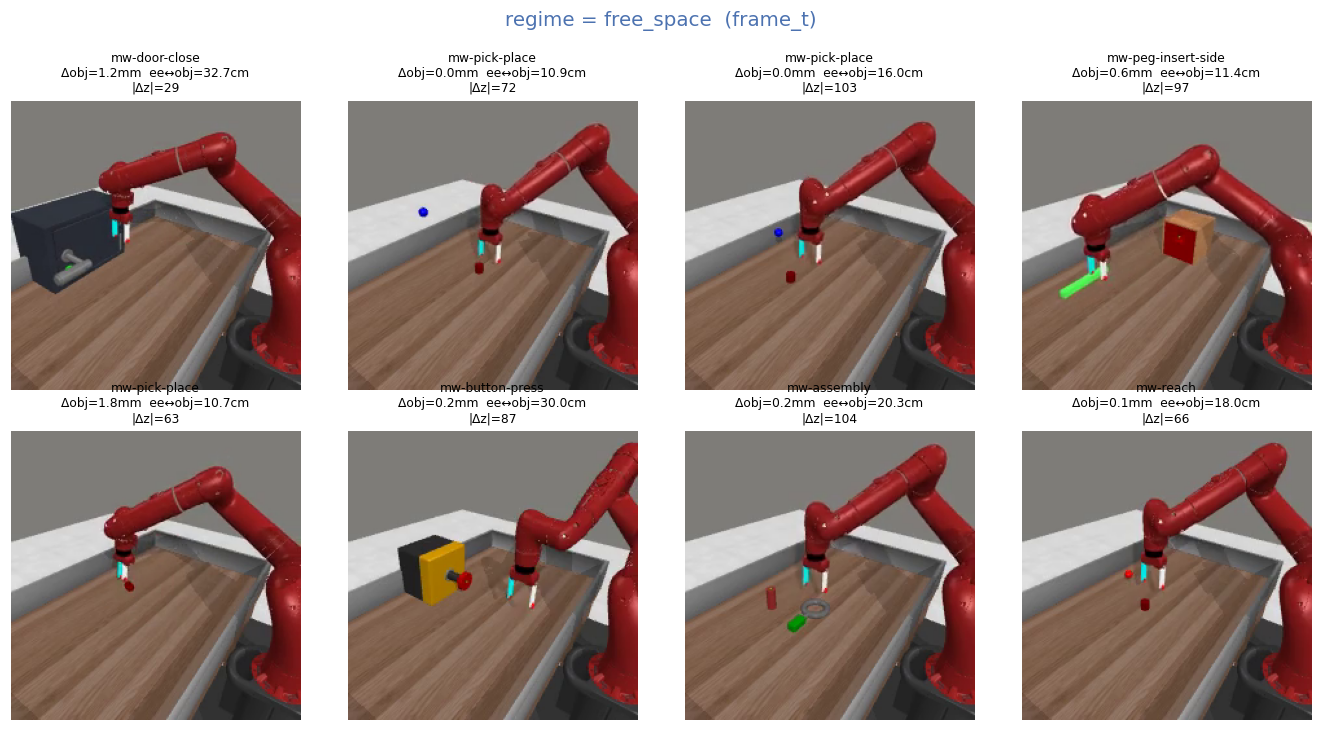

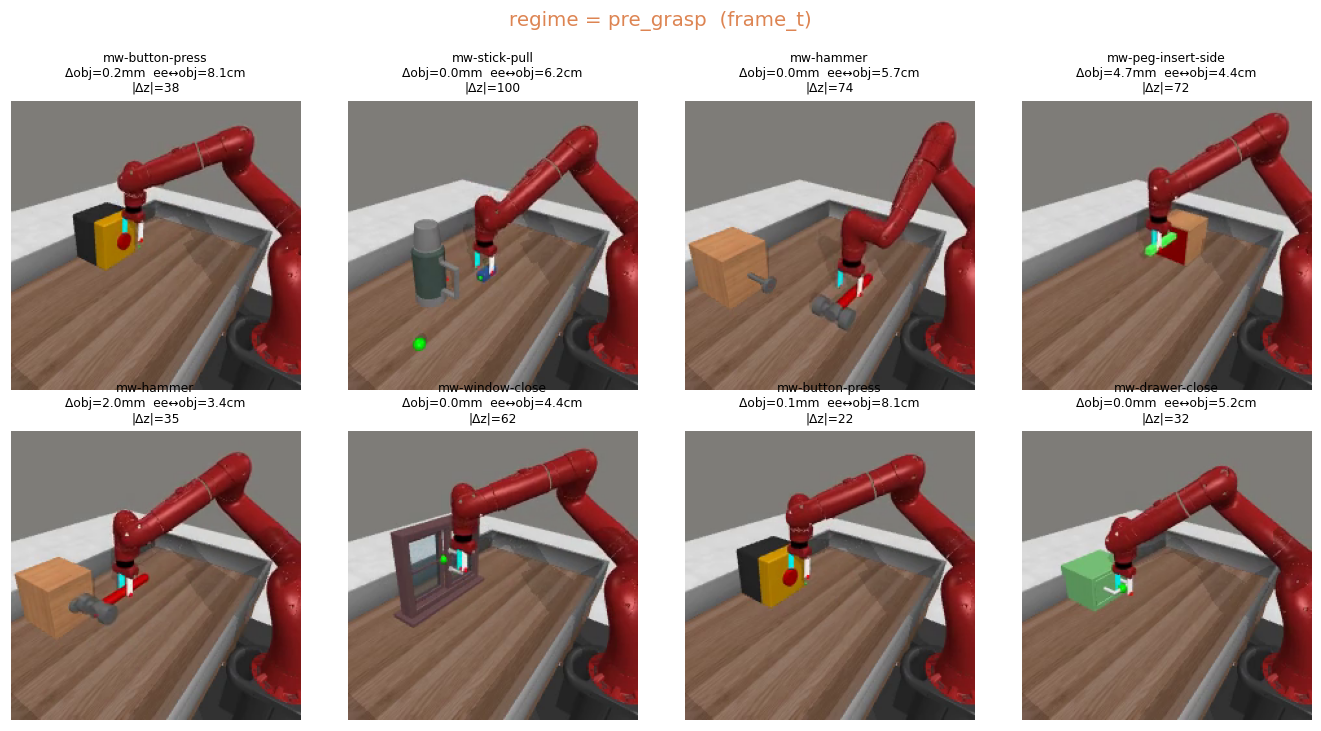

[gripper_actuation] empty — nothing to show


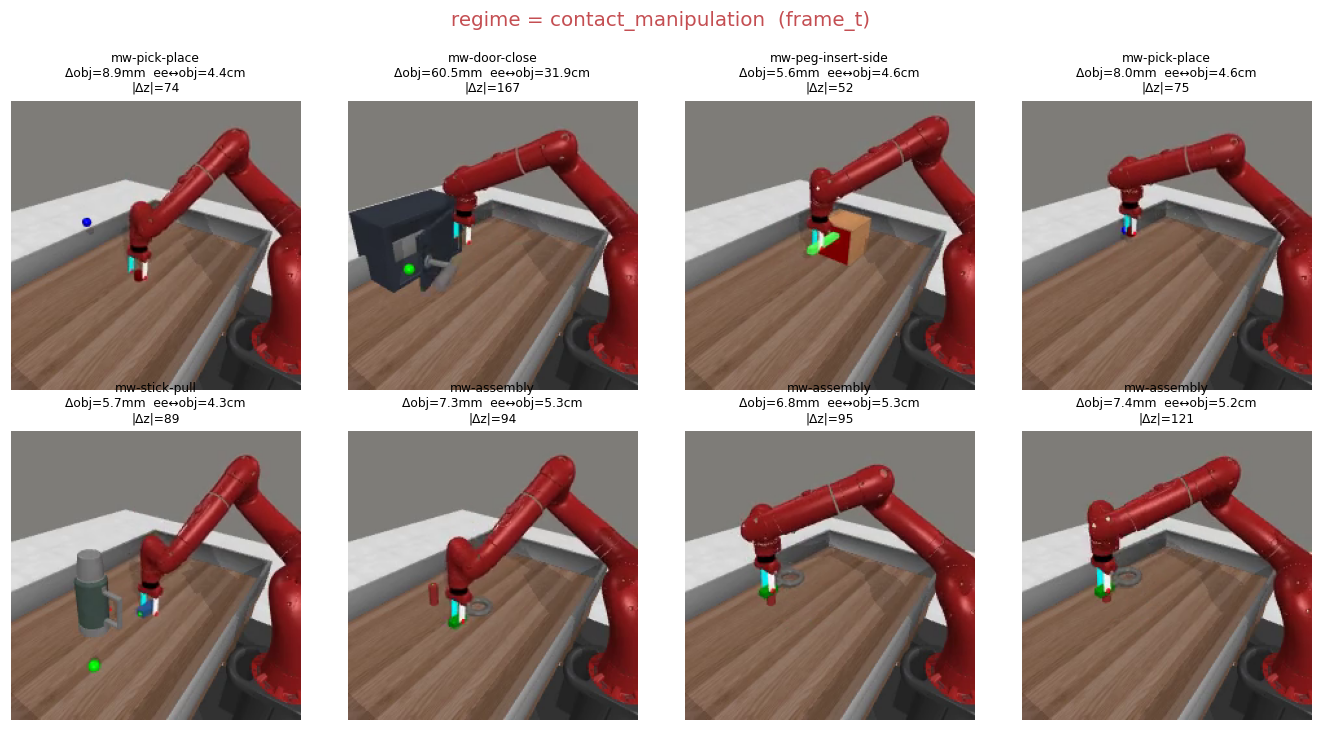

In [5]:
def regime_gallery(regime: str, n: int = 8, seed: int = 0, which: str = "t"):
    sub = df[df.regime == regime]
    if len(sub) == 0:
        print(f"[{regime}] empty — nothing to show"); return
    samp = sub.sample(min(n, len(sub)), random_state=seed)
    cols = min(4, len(samp)); rows = int(np.ceil(len(samp) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.1 * cols, 3.3 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes: ax.axis("off")
    for ax, (_, r) in zip(axes, samp.iterrows()):
        try:
            fr = load_frames(r.traj_id)
            idx = r.t if which == "t" else r.t + 1
            ax.imshow(fr[idx].astype(np.uint8))
        except Exception as e:
            ax.text(0.5, 0.5, f"frame err\n{e}", ha="center", va="center", fontsize=7)
        ax.set_title(f"{r.task}\nΔobj={r.obj_disp*1000:.1f}mm  ee↔obj={r.ee_obj*100:.1f}cm\n"
                     f"|Δz|={r.dz:.0f}", fontsize=8)
    fig.suptitle(f"regime = {regime}  (frame_{which})", color=REGIME_COLORS[regime],
                 fontsize=13, y=1.0)
    plt.tight_layout(); plt.show()

for rg in REGIMES:
    regime_gallery(rg, n=8)

### 4b · Action effect: `frame_t → frame_{t+1}` pairs

The same transitions shown as before/after pairs — makes the (often subtle)
visual effect of one action step explicit, especially in `pre_grasp`/`contact`.

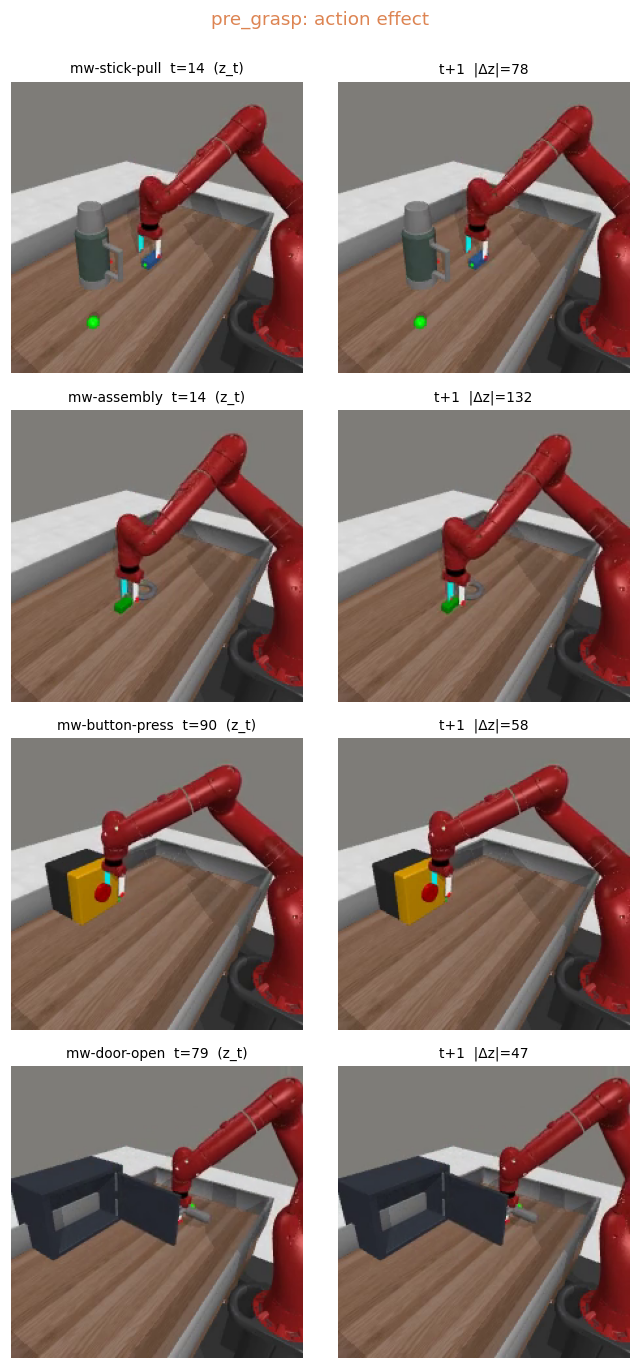

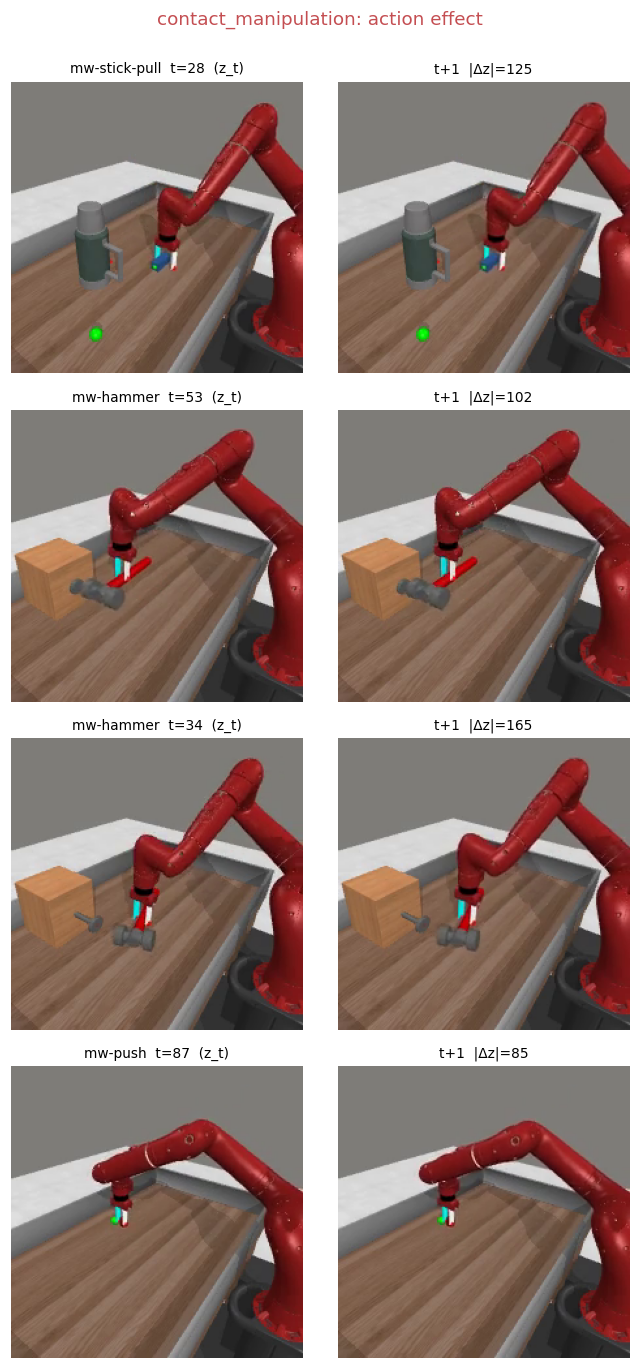

In [6]:
def before_after(regime: str, n: int = 4, seed: int = 1):
    sub = df[df.regime == regime]
    if len(sub) == 0:
        print(f"[{regime}] empty"); return
    samp = sub.sample(min(n, len(sub)), random_state=seed)
    fig, axes = plt.subplots(len(samp), 2, figsize=(6.2, 3.1 * len(samp)))
    axes = np.atleast_2d(axes)
    for i, (_, r) in enumerate(samp.iterrows()):
        try:
            fr = load_frames(r.traj_id)
            axes[i, 0].imshow(fr[r.t].astype(np.uint8))
            axes[i, 1].imshow(fr[r.t + 1].astype(np.uint8))
        except Exception as e:
            axes[i, 0].text(0.5, 0.5, str(e), fontsize=7, ha="center")
        axes[i, 0].set_title(f"{r.task}  t={r.t}  (z_t)", fontsize=9)
        axes[i, 1].set_title(f"t+1  |Δz|={r.dz:.0f}", fontsize=9)
        for a in axes[i]: a.axis("off")
    fig.suptitle(f"{regime}: action effect", color=REGIME_COLORS[regime], y=1.0)
    plt.tight_layout(); plt.show()

for rg in ["pre_grasp", "contact_manipulation"]:
    before_after(rg, n=4)

## 5 · Why each transition got its label — state-space view

The Metaworld proxy carves regimes from two scalars: **object displacement**
(contact) and **ee↔object distance** (pre-grasp), with gripper Δ on top. This
scatter shows the decision boundaries the stratifier actually applies.

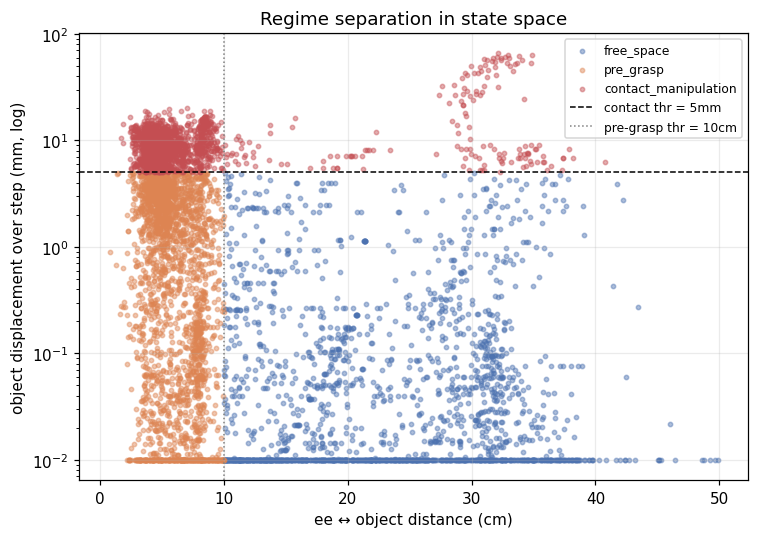

In [7]:
from stratification.metaworld_regimes import (
    OBJECT_MOVE_THRESHOLD, PRE_GRASP_DISTANCE, GRIPPER_DELTA_THRESHOLD)

samp = df.sample(min(6000, len(df)), random_state=0)
fig, ax = plt.subplots(figsize=(7, 5))
for rg in REGIMES:
    s = samp[samp.regime == rg]
    if len(s) == 0: continue
    ax.scatter(s.ee_obj * 100, np.maximum(s.obj_disp * 1000, 1e-2),
               s=8, alpha=0.45, label=rg, color=REGIME_COLORS[rg])
ax.axhline(OBJECT_MOVE_THRESHOLD * 1000, color="k", ls="--", lw=1,
           label=f"contact thr = {OBJECT_MOVE_THRESHOLD*1000:.0f}mm")
ax.axvline(PRE_GRASP_DISTANCE * 100, color="gray", ls=":", lw=1,
           label=f"pre-grasp thr = {PRE_GRASP_DISTANCE*100:.0f}cm")
ax.set_yscale("log")
ax.set_xlabel("ee ↔ object distance (cm)")
ax.set_ylabel("object displacement over step (mm, log)")
ax.set_title("Regime separation in state space")
ax.legend(fontsize=8, loc="upper right"); plt.tight_layout(); plt.show()

## 6 · Latent change ‖Δz‖ per regime + effect threshold

The decision metric is *effect-conditioned* CRA — computed only where
‖Δz‖ > τ (τ = median Δz). This shows the per-regime ‖Δz‖ distribution and what
fraction of each regime is "effectful".

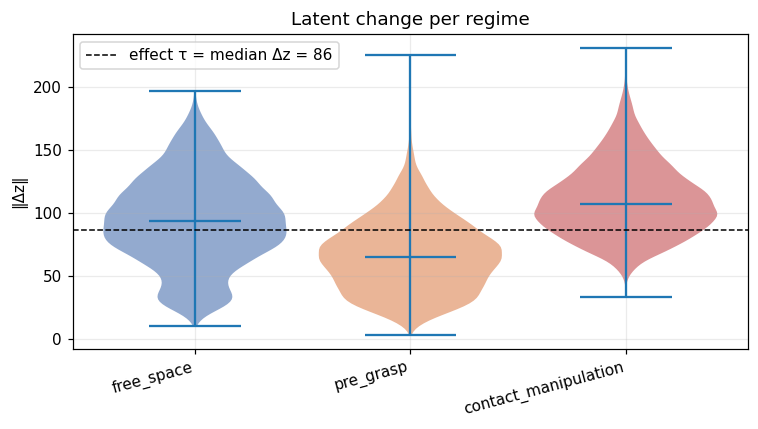

,% effectful (Δz>τ)
regime,
free_space,57.9
pre_grasp,24.0
contact_manipulation,79.0


In [8]:
tau = float(df.dz.median())
fig, ax = plt.subplots(figsize=(7, 4))
present = [r for r in REGIMES if (df.regime == r).any()]
data = [df.loc[df.regime == r, "dz"].values for r in present]
parts = ax.violinplot(data, showmedians=True, widths=0.85)
for pc, r in zip(parts["bodies"], present):
    pc.set_facecolor(REGIME_COLORS[r]); pc.set_alpha(0.6)
ax.axhline(tau, color="k", ls="--", lw=1, label=f"effect τ = median Δz = {tau:.0f}")
ax.set_xticks(range(1, len(present) + 1)); ax.set_xticklabels(present, rotation=15, ha="right")
ax.set_ylabel("‖Δz‖"); ax.set_title("Latent change per regime"); ax.legend()
plt.tight_layout(); plt.show()

eff = (df.assign(effectful=df.dz > tau)
         .groupby("regime")["effectful"].mean().reindex(present) * 100)
display(eff.round(1).to_frame("% effectful (Δz>τ)"))

## 7 · Per-task regime composition

Which tasks are contact-/pre-grasp-heavy — the thesis predicts the gap
concentrates in the contact-rich *hard* tasks.

C:\Users\Admin\AppData\Local\Temp\ipykernel_34768\257262154.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comp_frac.index, rotation=40, ha="right")


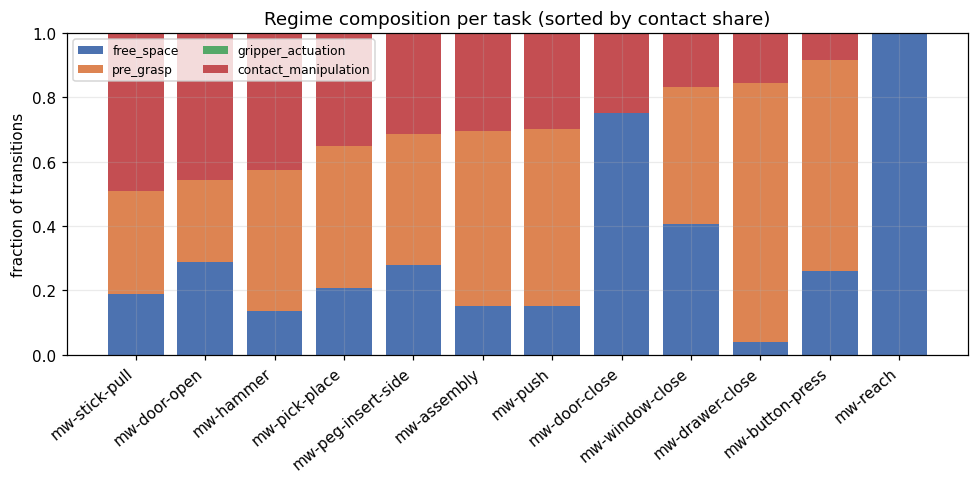

In [9]:
comp = (df.groupby(["task", "regime"]).size().unstack(fill_value=0)
          .reindex(columns=REGIMES, fill_value=0))
comp_frac = comp.div(comp.sum(axis=1), axis=0).fillna(0)
order = comp_frac["contact_manipulation"].sort_values(ascending=False).index
comp_frac = comp_frac.loc[order]

fig, ax = plt.subplots(figsize=(9, 4.5))
bottom = np.zeros(len(comp_frac))
for rg in REGIMES:
    ax.bar(comp_frac.index, comp_frac[rg], bottom=bottom,
           color=REGIME_COLORS[rg], label=rg)
    bottom += comp_frac[rg].values
ax.set_ylabel("fraction of transitions"); ax.set_ylim(0, 1)
ax.set_title("Regime composition per task (sorted by contact share)")
ax.set_xticklabels(comp_frac.index, rotation=40, ha="right")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

## 8 · The headline finding — CRA gap by strategy × regime

From `results/metaworld_diagnostic.csv`: models pass the easy `opposite`
counterfactual (~0.97) but collapse on `hard_nn`/`hard_effect` in
`pre_grasp`/`contact` — that dissociation *is* the action-grounding gap. Pooled
across tasks (transition-weighted), chance = 1/17 ≈ 0.059.

C:\Users\Admin\AppData\Local\Temp\ipykernel_34768\529850550.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  piv = (cra.groupby(["strategy", "regime"]).apply(wmean)


regime,free_space,pre_grasp,gripper_actuation,contact_manipulation
strategy,,,,
random,0.823,0.625,NaN,0.729
opposite,0.990,0.961,NaN,0.975
hard_nn,0.566,0.467,NaN,0.481
hard_effect,0.566,0.467,NaN,0.481


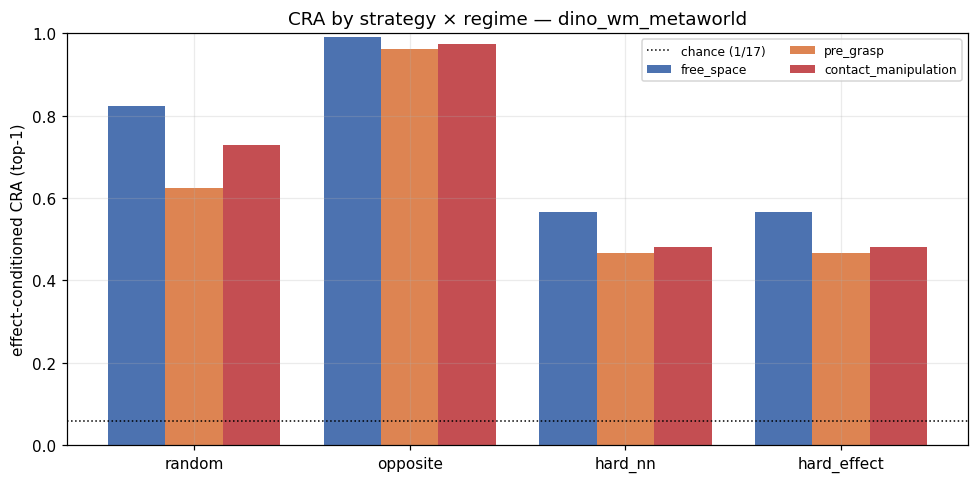

In [10]:
cra_path = RESULTS / "metaworld_diagnostic.csv"
cra = pd.read_csv(cra_path)
cra = cra[(cra.model == MODEL) & (cra.status == "ok")].copy()

def wmean(g):  # transition-weighted effect-conditioned CRA
    w = g["n_effect"].clip(lower=1)
    return np.average(g["cra_top1_eff"], weights=w)

piv = (cra.groupby(["strategy", "regime"]).apply(wmean)
          .unstack("regime").reindex(columns=REGIMES))
strat_order = [s for s in ["random", "opposite", "hard_nn", "hard_effect"] if s in piv.index]
piv = piv.loc[strat_order]
display(piv.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
present = [r for r in REGIMES if r in piv.columns and piv[r].notna().any()]
x = np.arange(len(strat_order)); w = 0.8 / max(len(present), 1)
for i, rg in enumerate(present):
    ax.bar(x + i * w, piv[rg].values, w, label=rg, color=REGIME_COLORS[rg])
ax.axhline(1 / 17, color="k", ls=":", lw=1, label="chance (1/17)")
ax.set_xticks(x + w * (len(present) - 1) / 2); ax.set_xticklabels(strat_order)
ax.set_ylabel("effect-conditioned CRA (top-1)"); ax.set_ylim(0, 1)
ax.set_title(f"CRA by strategy × regime — {MODEL}")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

## 9 · Boundary-Blindness by regime (+ the object-dynamics fix)

`bb_boundary` on the bifurcation subset — high where the model is blind to the
boundary. The gate found `pre_grasp` ≫ `free_space`; the `+obj_dynamics` fix
(`17_train_object_dynamics.py`) roughly halves it. Reads
`metaworld_boundary.csv` and `metaworld_boundary_dynamics.csv`.

C:\Users\Admin\AppData\Local\Temp\ipykernel_34768\559994910.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[col], weights=g["w"]))
C:\Users\Admin\AppData\Local\Temp\ipykernel_34768\559994910.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[col], weights=g["w"]))


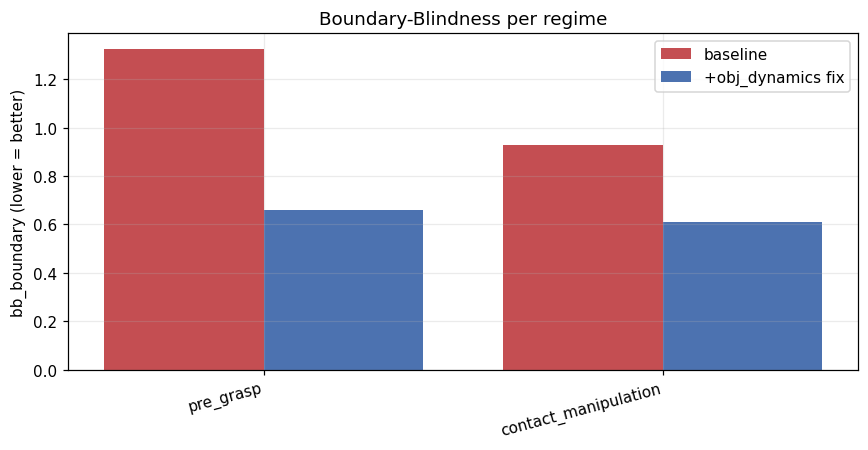

,baseline,fixed
regime,,
free_space,NaN,NaN
pre_grasp,1.323,0.660
gripper_actuation,NaN,NaN
contact_manipulation,0.929,0.611


In [11]:
def pooled_bb(path, col="bb_boundary"):
    if not Path(path).exists():
        return None
    b = pd.read_csv(path)
    b = b[b.status == "ok"]
    if "model" in b and b.model.str.startswith(MODEL).any():
        b = b[b.model.str.startswith(MODEL)]
    w = b["n_boundary"].clip(lower=1)
    return (b.assign(w=w).groupby("regime")
             .apply(lambda g: np.average(g[col], weights=g["w"]))
             .reindex(REGIMES))

base = pooled_bb(RESULTS / "metaworld_boundary.csv")
fixed = pooled_bb(RESULTS / "metaworld_boundary_dynamics.csv")

fig, ax = plt.subplots(figsize=(8, 4.2))
present = [r for r in REGIMES if base is not None and pd.notna(base.get(r))]
x = np.arange(len(present))
ax.bar(x - 0.2, [base[r] for r in present], 0.4, label="baseline", color="#C44E52")
if fixed is not None:
    ax.bar(x + 0.2, [fixed.get(r, np.nan) for r in present], 0.4,
           label="+obj_dynamics fix", color="#4C72B0")
ax.set_xticks(x); ax.set_xticklabels(present, rotation=15, ha="right")
ax.set_ylabel("bb_boundary (lower = better)")
ax.set_title("Boundary-Blindness per regime"); ax.legend()
plt.tight_layout(); plt.show()
if base is not None: display(pd.DataFrame({"baseline": base, "fixed": fixed}).round(3))

## 10 · Sanity checks

In [12]:
checks = []
checks.append(("cache + sidecar present", CACHE.exists() and SIDECAR.exists()))
checks.append(("transitions loaded", len(df) > 0))
checks.append(("gripper_actuation empty on MW (expected)",
               (df.regime == "gripper_actuation").sum() == 0))
checks.append(("contact has largest object displacement",
               df.groupby("regime").obj_disp.median().idxmax() == "contact_manipulation"))
checks.append(("pre_grasp closer to object than free_space",
               df.loc[df.regime == "pre_grasp", "ee_obj"].median()
               < df.loc[df.regime == "free_space", "ee_obj"].median()))
try:
    load_frames(df.traj_id.iloc[0]); checks.append(("frame loader + alignment OK", True))
except Exception as e:
    checks.append((f"frame loader ({e})", False))

for name, ok in checks:
    print(("PASS" if ok else "FAIL"), "-", name)
n_fail = sum(1 for _, ok in checks if not ok)
print(f"\n{len(checks) - n_fail}/{len(checks)} checks passed")

PASS - cache + sidecar present
PASS - transitions loaded
PASS - gripper_actuation empty on MW (expected)
PASS - contact has largest object displacement
PASS - pre_grasp closer to object than free_space
PASS - frame loader + alignment OK

6/6 checks passed


---
# Part 2 · DROID — real Franka manipulation

DROID is the secondary diagnostic: a real robot with a **real gripper signal**,
so the two regimes Metaworld leaves empty/sparse — `gripper_actuation` and
`contact_manipulation` — actually populate. Frames here are the **wrist camera**,
decoded with `decord` (which works locally, unlike the Metaworld `torchcodec`
path), re-running the exact build-order pass so frames align with the cached
`z`/regime labels (verified per trajectory against the cached `state`).

## D0 · DROID setup

In [13]:
DROID_MODEL = "dino_wm_droid"
DROID_CACHE = ROOT / "data" / "precomputed_latents" / f"droid__{DROID_MODEL}.h5"
DROID_SIDECAR = DROID_CACHE.with_name(DROID_CACHE.name + ".regimes.json")
DROID_HAVE = DROID_CACHE.exists() and DROID_SIDECAR.exists()
print("DROID cache:", DROID_CACHE, "| present:", DROID_HAVE)

# DROID state = [cartesian_position(6), gripper(1)]; no object position.
DGRIP = 6
if not DROID_HAVE:
    print("DROID cache missing — run 03/04 on configs/diagnostic_droid.yaml. "
          "The DROID cells below will no-op.")

DROID cache: e:\code-project\jepa-research\diagnosis\data\precomputed_latents\droid__dino_wm_droid.h5 | present: True


## D1 · Per-transition table + regime distribution

The DROID stratifier (no object GT) is **gripper-primary**: large gripper Δ →
`gripper_actuation`; gripper held **closed** → `contact_manipulation` (holding /
in contact with an object, regardless of motion); gripper **open** then split by
scene change vs the dataset-median ‖Δz‖ → `pre_grasp` (above = approaching) vs
`free_space` (below = empty-space motion). Contact is *not* Δz-gated, so a
static-holding step is no longer mislabeled `free_space`. Unlike Metaworld,
**all four regimes populate**.

2,331 DROID transitions, 333 clips; median Δz baseline = 619


,n_transitions,pct
regime,,
free_space,409,17.5
pre_grasp,522,22.4
gripper_actuation,400,17.2
contact_manipulation,1000,42.9


C:\Users\Admin\AppData\Local\Temp\ipykernel_34768\457400502.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dcounts.index, rotation=20, ha="right")


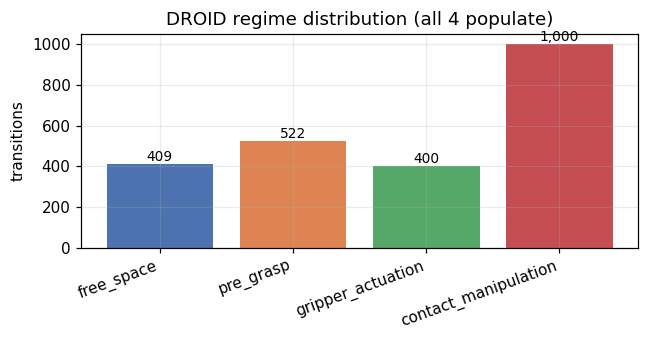

In [14]:
if DROID_HAVE:
    dreg = {k: np.asarray(v, np.int8) for k, v in json.load(open(DROID_SIDECAR)).items()}
    rows = []
    with h5py.File(DROID_CACHE, "r") as h:
        grp = h["trajectories"]
        for key in grp.keys():
            g = grp[key]; tid = g.attrs.get("traj_id", key)
            z = g["z"][:]; zf = z.reshape(z.shape[0], -1)
            grip = g["gripper"][:] if "gripper" in g else g["state"][:, DGRIP]
            reg = dreg.get(tid)
            if reg is None: continue
            for t in range(len(reg)):
                rows.append(dict(traj_id=tid, tidx=int(tid.split("/")[1]), t=t,
                                 regime=ID_TO_REGIME[int(reg[t])],
                                 grip=float(grip[t]),
                                 grip_delta=float(abs(grip[t + 1] - grip[t])),
                                 dz=float(np.linalg.norm(zf[t + 1] - zf[t]))))
    ddf = pd.DataFrame(rows)
    DBASE = float(ddf.dz.median())   # stratifier baseline (median latent change)
    print(f"{len(ddf):,} DROID transitions, {ddf.traj_id.nunique()} clips; "
          f"median Δz baseline = {DBASE:.0f}")

    dcounts = ddf.regime.value_counts().reindex(REGIMES).fillna(0).astype(int)
    display(dcounts.to_frame("n_transitions").assign(pct=(100 * dcounts / dcounts.sum()).round(1)))
    fig, ax = plt.subplots(figsize=(6, 3.2))
    ax.bar(dcounts.index, dcounts.values, color=[REGIME_COLORS[r] for r in dcounts.index])
    ax.set_ylabel("transitions"); ax.set_title("DROID regime distribution (all 4 populate)")
    ax.set_xticklabels(dcounts.index, rotation=20, ha="right")
    for i, v in enumerate(dcounts.values): ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

## D2 · DROID wrist-frame loader (decord, alignment-checked)

One ordered pass via the production `iterate_droid_trajectories` (same seed &
call order as the cache build → identical sampled frames), collecting only the
clips we will display. Each is verified against the cached `state`; mismatches
are dropped with a warning. Frames downsampled for display memory.

In [15]:
import logging, cv2
logging.getLogger().setLevel(logging.ERROR)

DROID_FRAME_POOL = 100   # only sample gallery clips from the first N (bounds decode cost)

def collect_droid_frames(needed_tids):
    # one ordered pass; returns {tid: frames (T,h,w,3) uint8}, alignment-verified
    import yaml as _yaml
    from data import iterate_droid_trajectories
    dcfg = _yaml.safe_load(open(ROOT / "configs" / "diagnostic_droid.yaml"))["dataset"]
    needed = set(needed_tids)
    if not needed: return {}
    max_idx = max(int(t.split("/")[1]) for t in needed)
    it = iterate_droid_trajectories(
        root=str(ROOT / dcfg["root"]), max_transitions=10 ** 9,
        external_root=str(ROOT / "external" / "jepa-wms"),
        dataset_kwargs=dcfg.get("dataset_kwargs"))
    out = {}
    with h5py.File(DROID_CACHE, "r") as h:
        for k, tb in enumerate(it):
            if k > max_idx: break
            if tb.traj_id not in needed: continue
            cst = h["trajectories"][tb.traj_id.replace("/", "--SLASH--")]["state"][:]
            if not np.allclose(np.asarray(tb.state)[:cst.shape[0]], cst, atol=1e-3):
                print("  [warn] state mismatch, skipping", tb.traj_id); continue
            v = tb.obs_visual.permute(0, 2, 3, 1).numpy().astype(np.uint8)  # T,H,W,C
            v = np.stack([cv2.resize(f, (336, 188)) for f in v])
            out[tb.traj_id] = v
    return out

# warm a tiny sample to validate the path
if DROID_HAVE:
    _probe = ddf[ddf.tidx < 3].traj_id.unique()[:2].tolist()
    _f = collect_droid_frames(_probe)
    print("probe frames:", {t: v.shape for t, v in _f.items()})

Loading 1 DROID eps to compute mean/std: 100%|██████████| 1/1 [00:00<00:00,  5.08it/s]


probe frames: {'droid/000000': (8, 188, 336, 3), 'droid/000001': (8, 188, 336, 3)}


## D3 · DROID regime gallery — real wrist-camera frames

decoding 21 clips (up to idx 98)...


Loading 1 DROID eps to compute mean/std: 100%|██████████| 1/1 [00:00<00:00,  9.00it/s]


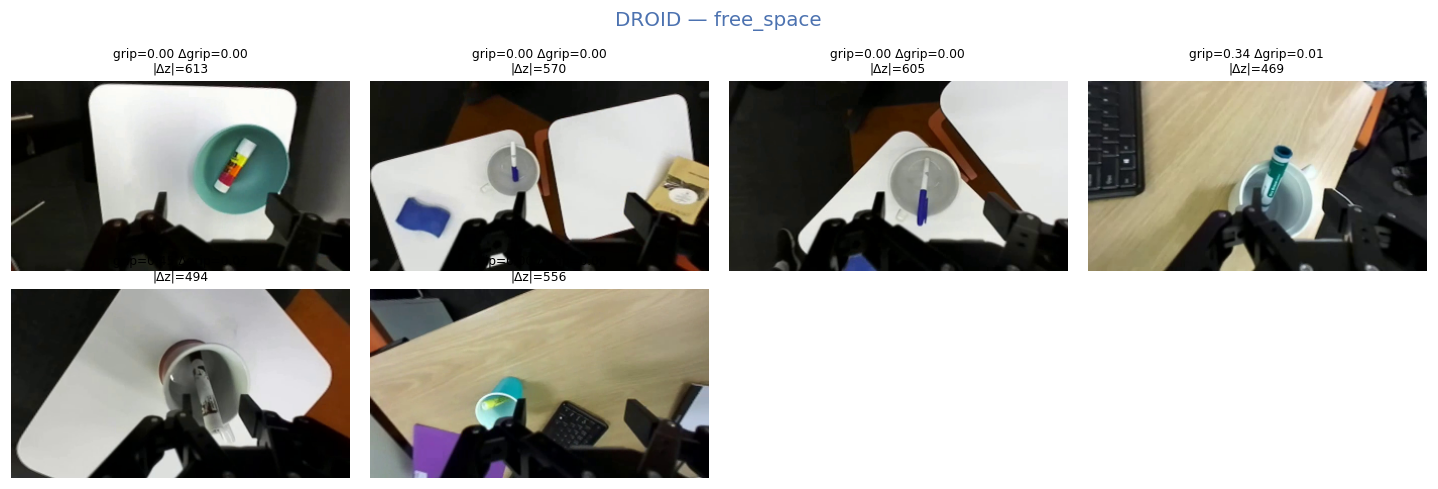

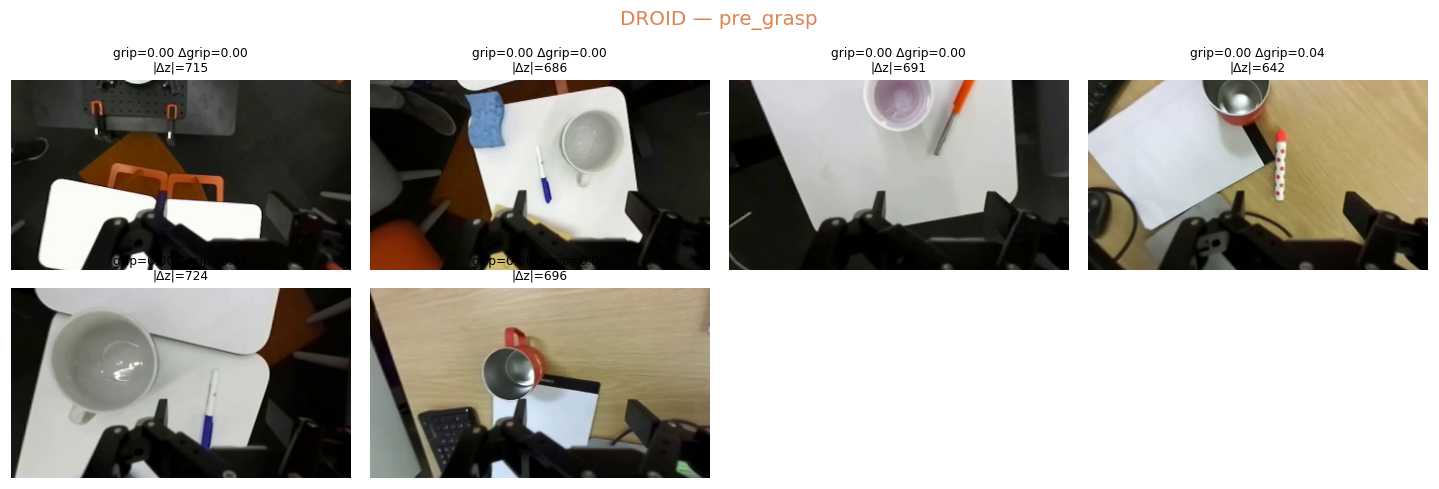

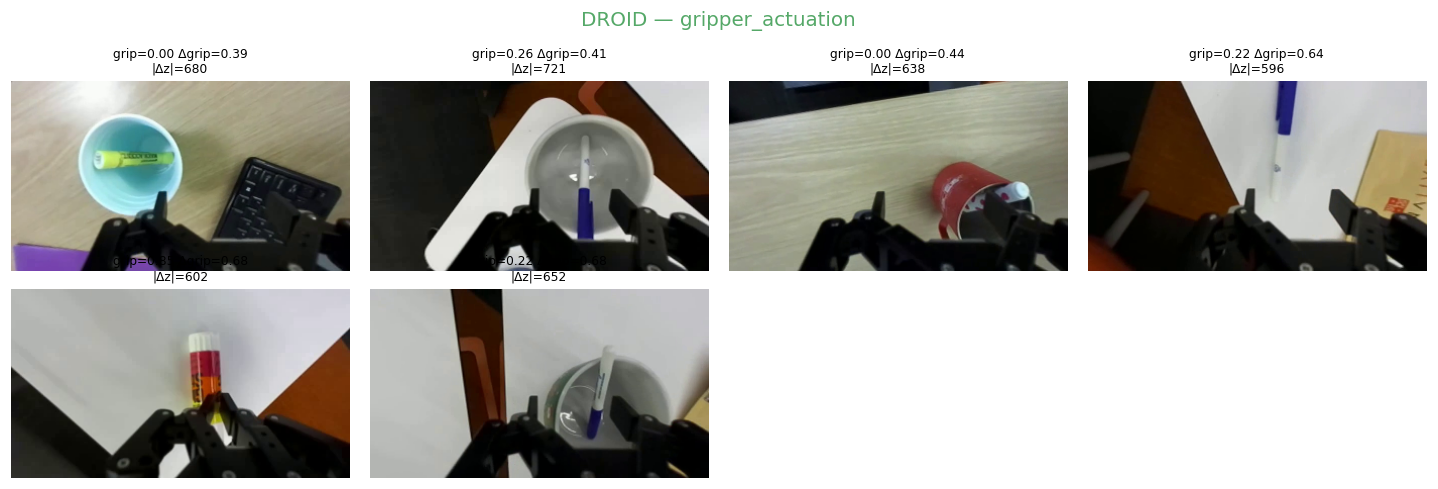

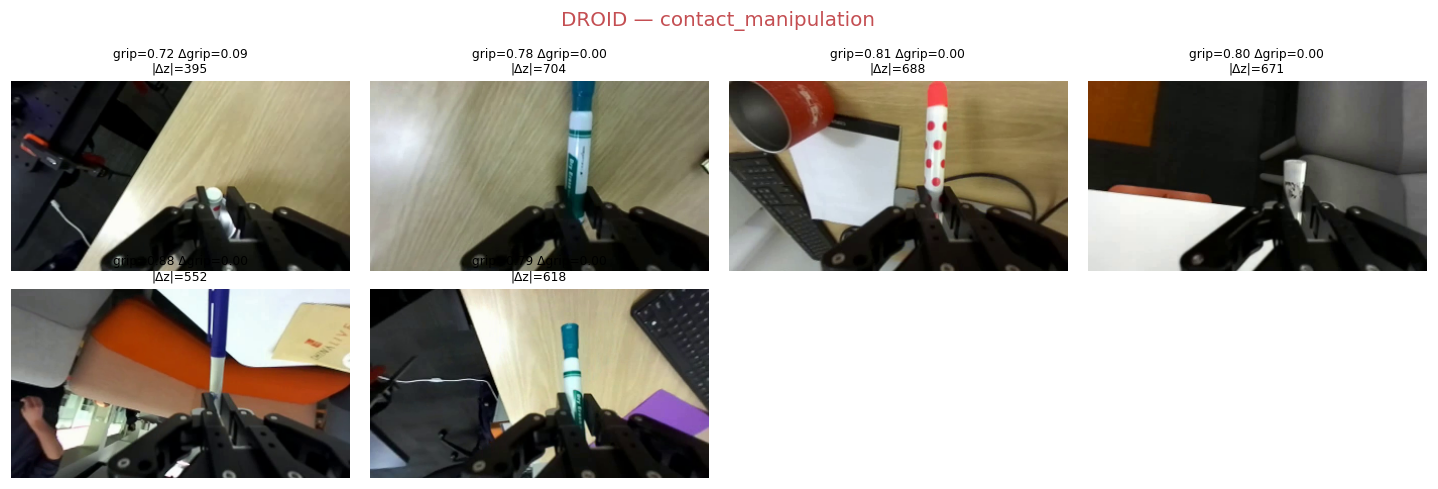

In [16]:
if DROID_HAVE:
    pool = ddf[ddf.tidx < DROID_FRAME_POOL]
    picks = {}
    for rg in REGIMES:
        s = pool[pool.regime == rg]
        if len(s): picks[rg] = s.sample(min(6, len(s)), random_state=0)
    need = sorted({r.traj_id for d in picks.values() for _, r in d.iterrows()})
    print(f"decoding {len(need)} clips (up to idx {max(int(t.split('/')[1]) for t in need)})...")
    DFRAMES = collect_droid_frames(need)

    for rg, samp in picks.items():
        samp = samp[samp.traj_id.isin(DFRAMES)]
        if len(samp) == 0:
            print(f"[{rg}] no decoded frames"); continue
        cols = min(4, len(samp)); rows_ = int(np.ceil(len(samp) / cols))
        fig, axes = plt.subplots(rows_, cols, figsize=(3.3 * cols, 2.2 * rows_))
        axes = np.atleast_1d(axes).ravel()
        for ax in axes: ax.axis("off")
        for ax, (_, r) in zip(axes, samp.iterrows()):
            ax.imshow(DFRAMES[r.traj_id][r.t]); ax.axis("off")
            ax.set_title(f"grip={r.grip:.2f} Δgrip={r.grip_delta:.2f}\n|Δz|={r.dz:.0f}", fontsize=8)
        fig.suptitle(f"DROID — {rg}", color=REGIME_COLORS[rg], fontsize=13, y=1.0)
        plt.tight_layout(); plt.show()

## D4 · How DROID regimes are defined — gripper-primary

`gripper_actuation` is set by gripper **Δ** (left: it dominates the Δgrip tail).
The rest split on the **gripper-closed line** (right, vertical): closed →
`contact_manipulation` for *any* ‖Δz‖ (in contact / holding); open → `pre_grasp`
if ‖Δz‖ is above the median baseline (scene changing → approaching), else
`free_space`. Note every `contact` point sits right of the closed line and every
`free_space` point sits left of it and below the baseline — closed-gripper steps
are no longer dumped into `free_space`.

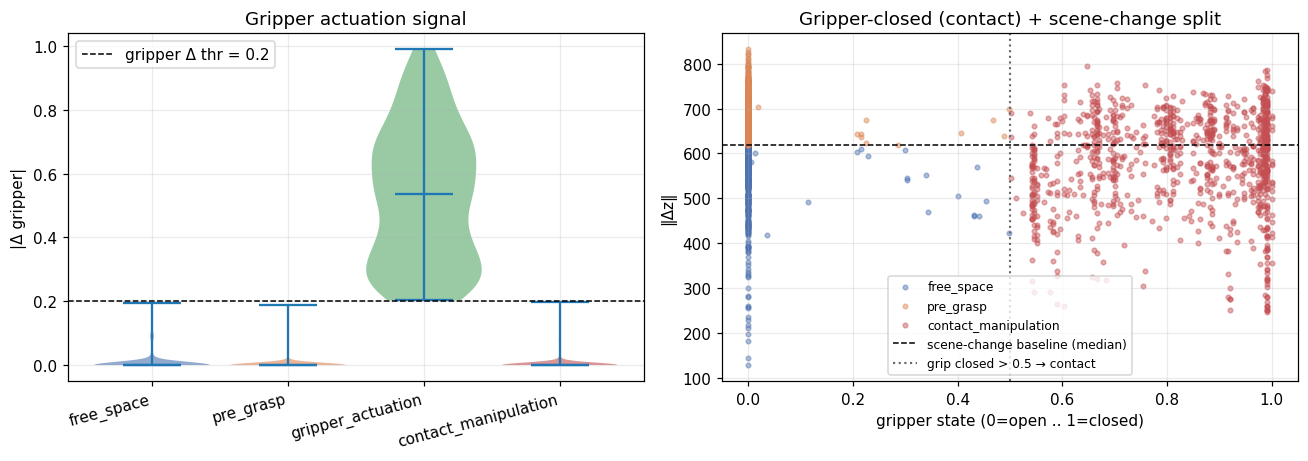

In [17]:
if DROID_HAVE:
    from stratification.droid_regimes import (
        GRIPPER_DELTA_THRESHOLD, GRIPPER_CLOSED_THRESHOLD, SCENE_CHANGE_RATIO)
    present = [r for r in REGIMES if (ddf.regime == r).any()]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.3))

    # left: gripper-delta per regime (gripper_actuation is the high tail)
    data = [ddf.loc[ddf.regime == r, "grip_delta"].values for r in present]
    parts = a1.violinplot(data, showmedians=True, widths=0.85)
    for pc, r in zip(parts["bodies"], present): pc.set_facecolor(REGIME_COLORS[r]); pc.set_alpha(0.6)
    a1.axhline(GRIPPER_DELTA_THRESHOLD, color="k", ls="--", lw=1,
               label=f"gripper Δ thr = {GRIPPER_DELTA_THRESHOLD}")
    a1.set_xticks(range(1, len(present) + 1)); a1.set_xticklabels(present, rotation=15, ha="right")
    a1.set_ylabel("|Δ gripper|"); a1.set_title("Gripper actuation signal"); a1.legend()

    # right: gripper-closed line (contact) + scene-change baseline (pre_grasp/free split)
    s = ddf[ddf.regime != "gripper_actuation"].sample(min(5000, (ddf.regime != "gripper_actuation").sum()), random_state=0)
    for r in present:
        if r == "gripper_actuation": continue
        ss = s[s.regime == r]
        a2.scatter(ss.grip, ss.dz, s=9, alpha=0.45, color=REGIME_COLORS[r], label=r)
    a2.axhline(SCENE_CHANGE_RATIO * DBASE, color="k", ls="--", lw=1, label="scene-change baseline (median)")
    a2.axvline(GRIPPER_CLOSED_THRESHOLD, color="dimgray", ls=":", lw=1.4,
               label=f"grip closed > {GRIPPER_CLOSED_THRESHOLD} → contact")
    a2.set_xlabel("gripper state (0=open .. 1=closed)"); a2.set_ylabel("‖Δz‖")
    a2.set_title("Gripper-closed (contact) + scene-change split"); a2.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## D5 · DROID CRA gap by strategy × regime

C:\Users\Admin\AppData\Local\Temp\ipykernel_34768\4124440878.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dpiv = (dc.groupby(["strategy", "regime"]).apply(wmean)


regime,free_space,pre_grasp,gripper_actuation,contact_manipulation
strategy,,,,
random,NaN,0.372,0.314,0.449
opposite,NaN,0.046,0.057,0.162
hard_nn,NaN,0.070,0.035,0.056
hard_effect,NaN,0.070,0.035,0.056


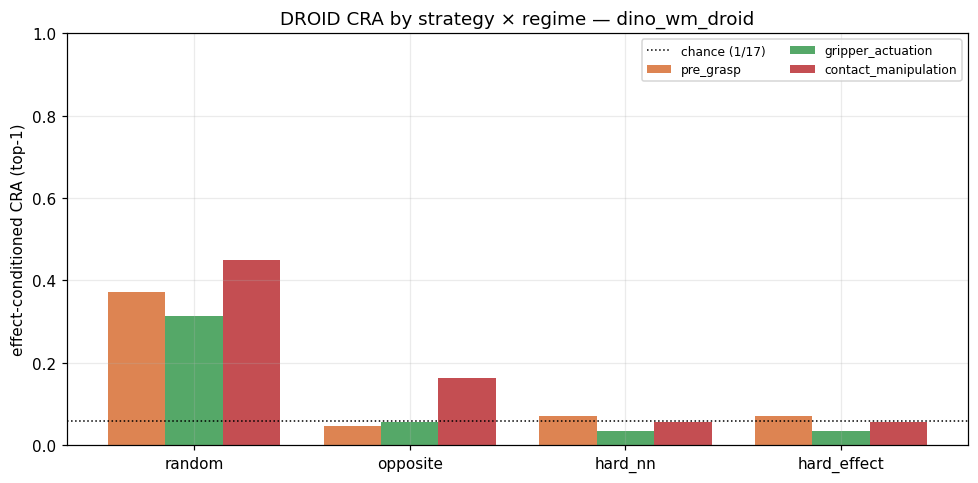

In [18]:
dpath = RESULTS / "droid_diagnostic.csv"
if dpath.exists():
    dc = pd.read_csv(dpath)
    dc = dc[(dc.model == DROID_MODEL) & (dc.status == "ok")].copy()
    dpiv = (dc.groupby(["strategy", "regime"]).apply(wmean)
              .unstack("regime").reindex(columns=REGIMES))
    so = [s for s in ["random", "opposite", "hard_nn", "hard_effect"] if s in dpiv.index]
    dpiv = dpiv.loc[so]; display(dpiv.round(3))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    present = [r for r in REGIMES if r in dpiv.columns and dpiv[r].notna().any()]
    x = np.arange(len(so)); w = 0.8 / max(len(present), 1)
    for i, rg in enumerate(present):
        ax.bar(x + i * w, dpiv[rg].values, w, label=rg, color=REGIME_COLORS[rg])
    ax.axhline(1 / 17, color="k", ls=":", lw=1, label="chance (1/17)")
    ax.set_xticks(x + w * (len(present) - 1) / 2); ax.set_xticklabels(so)
    ax.set_ylabel("effect-conditioned CRA (top-1)"); ax.set_ylim(0, 1)
    ax.set_title(f"DROID CRA by strategy × regime — {DROID_MODEL}")
    ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()
else:
    print("results/droid_diagnostic.csv missing")

## D6 · DROID Boundary-Blindness by regime (+ object-dynamics fix)

C:\Users\Admin\AppData\Local\Temp\ipykernel_34768\784598352.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[col], weights=g["w"])).reindex(REGIMES))
C:\Users\Admin\AppData\Local\Temp\ipykernel_34768\784598352.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[col], weights=g["w"])).reindex(REGIMES))


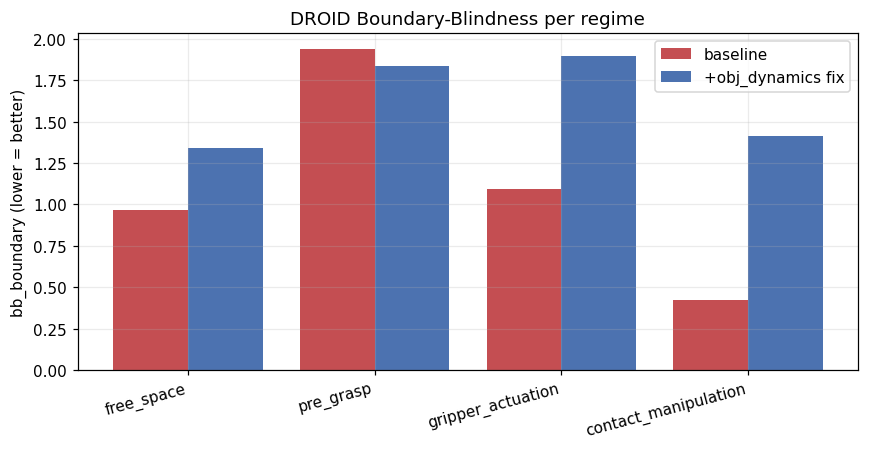

,baseline,fixed
regime,,
free_space,0.968,1.338
pre_grasp,1.939,1.839
gripper_actuation,1.093,1.895
contact_manipulation,0.421,1.412


In [19]:
def pooled_bb_any(path, col="bb_boundary"):
    if not Path(path).exists(): return None
    b = pd.read_csv(path); b = b[b.status == "ok"]
    w = b["n_boundary"].clip(lower=1)
    return (b.assign(w=w).groupby("regime")
             .apply(lambda g: np.average(g[col], weights=g["w"])).reindex(REGIMES))

dbase = pooled_bb_any(RESULTS / "droid_boundary.csv")
dfix = pooled_bb_any(RESULTS / "droid_boundary_dynamics.csv")
if dbase is not None:
    present = [r for r in REGIMES if pd.notna(dbase.get(r))]
    x = np.arange(len(present))
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.bar(x - 0.2, [dbase[r] for r in present], 0.4, label="baseline", color="#C44E52")
    if dfix is not None:
        ax.bar(x + 0.2, [dfix.get(r, np.nan) for r in present], 0.4,
               label="+obj_dynamics fix", color="#4C72B0")
    ax.set_xticks(x); ax.set_xticklabels(present, rotation=15, ha="right")
    ax.set_ylabel("bb_boundary (lower = better)")
    ax.set_title("DROID Boundary-Blindness per regime"); ax.legend()
    plt.tight_layout(); plt.show()
    display(pd.DataFrame({"baseline": dbase, "fixed": dfix}).round(3))
else:
    print("results/droid_boundary.csv missing")

## D7 · DROID sanity checks

In [20]:
if DROID_HAVE:
    from stratification.droid_regimes import GRIPPER_CLOSED_THRESHOLD as _GCT
    dchecks = [
        ("DROID cache + sidecar present", DROID_HAVE),
        ("all four regimes populate on DROID",
         all((ddf.regime == r).any() for r in REGIMES)),
        ("gripper_actuation has the largest |Δ gripper|",
         ddf.groupby("regime").grip_delta.median().idxmax() == "gripper_actuation"),
        ("contact gripper more closed than pre_grasp",
         ddf.loc[ddf.regime == "contact_manipulation", "grip"].median()
         > ddf.loc[ddf.regime == "pre_grasp", "grip"].median()),
        ("no closed-gripper step labeled free_space (the fix)",
         (ddf.loc[ddf.regime == "free_space", "grip"] > _GCT).sum() == 0),
        ("every contact step has a closed gripper",
         (ddf.loc[ddf.regime == "contact_manipulation", "grip"] > _GCT).all()),
    ]
    for name, ok in dchecks:
        print(("PASS" if ok else "FAIL"), "-", name)
    print(f"\n{sum(ok for _, ok in dchecks)}/{len(dchecks)} DROID checks passed")

PASS - DROID cache + sidecar present
PASS - all four regimes populate on DROID
PASS - gripper_actuation has the largest |Δ gripper|
PASS - contact gripper more closed than pre_grasp
PASS - no closed-gripper step labeled free_space (the fix)
PASS - every contact step has a closed gripper

6/6 DROID checks passed


---
# Part 3 · Other datasets & the diagnostic scaling curve

Parts 1–2 cover the two diagnostics with frame galleries (Metaworld, DROID).
This part adds the **remaining datasets** — the toy free-space tasks
(`pusht`, `point_maze`, `wall`), the small real-Franka set (`franka_custom`) — and
visualizes the **diagnostic results** across all of them, including the new
**DROID encoder-scaling curve** (22M → 300M → 1B).

All cells here are frame-free (sidecars + caches + result CSVs only), so they run
on the cluster box that has no Metaworld parquet / no Jupyter frame stack.

## P3.0 · Setup (self-contained)

In [ ]:
import sys, json, glob
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, h5py
import matplotlib.pyplot as plt, matplotlib as mpl

mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25

def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "precomputed_latents").is_dir() and (p / "stratification").is_dir():
            return p
    raise FileNotFoundError("diagnosis/ root not found")
ROOT = _find_root(Path.cwd()); sys.path.insert(0, str(ROOT))
PL = ROOT / "data" / "precomputed_latents"
RESULTS = ROOT / "results"

REGIMES = ["free_space", "pre_grasp", "gripper_actuation", "contact_manipulation"]
REGIME_COLORS = {"free_space": "#4C72B0", "pre_grasp": "#DD8452",
                 "gripper_actuation": "#55A868", "contact_manipulation": "#C44E52"}
ID_TO_REGIME = {0: "free_space", 1: "pre_grasp", 2: "gripper_actuation", 3: "contact_manipulation"}

# dataset -> (sidecar model used for regimes, diagnostic CSV, model col in CSV)
DATASETS = {
    "metaworld":     ("dino_wm_metaworld",  "metaworld_diagnostic.csv",     "dino_wm_metaworld"),
    "droid":         ("dino_wm_droid",      "droid_diagnostic.csv",         "dino_wm_droid"),
    "franka_custom": ("dino_wm_droid",      "franka_custom_diagnostic.csv", "dino_wm_droid"),
    "pusht":         ("dino_wm_pusht",      "pusht_diagnostic.csv",         "dino_wm_pusht"),
    "point_maze":    ("dino_wm_pointmaze",  "point_maze_diagnostic.csv",    "dino_wm_pointmaze"),
    "wall":          ("dino_wm_wall",       "wall_diagnostic.csv",          "dino_wm_wall"),
}

def sidecar_for(dataset, model=None):
    if model:
        p = PL / f"{dataset}__{model}.h5.regimes.json"
        if p.exists(): return p
    hits = sorted(PL.glob(f"{dataset}__*.h5.regimes.json"))
    return hits[0] if hits else None

def regime_counts(dataset, model=None):
    sc = sidecar_for(dataset, model)
    if sc is None: return None
    d = json.load(open(sc))
    c = Counter()
    for v in d.values(): c.update(np.asarray(v).tolist())
    return pd.Series({ID_TO_REGIME[k]: c.get(k, 0) for k in range(4)}).reindex(REGIMES).fillna(0).astype(int)

print("root:", ROOT)
print("sidecars present:", [d for d in DATASETS if sidecar_for(d, DATASETS[d][0])])

root: /home/nhatnc129/nhat.nc/jepa-research/diagnosis
sidecars present: ['droid', 'franka_custom', 'pusht', 'point_maze', 'wall']


## P3.1 · Regime distribution across every dataset

How each dataset populates the four manipulation regimes. The **toy** tasks
(`pusht`/`point_maze`/`wall`) are pure `free_space` (2-D point dynamics, no
gripper/contact). **Metaworld** lacks a usable gripper signal. Only the real
robots (`droid`, `franka_custom`) populate all four — which is why DROID is the
load-bearing diagnostic for the contact/gripper regimes.

,free_space,pre_grasp,gripper_actuation,contact_manipulation,total
droid,409,522,400,1000,2331
franka_custom,24,41,18,29,112
pusht,2493,0,0,0,2493
point_maze,20097,0,0,0,20097
wall,20041,0,0,0,20041


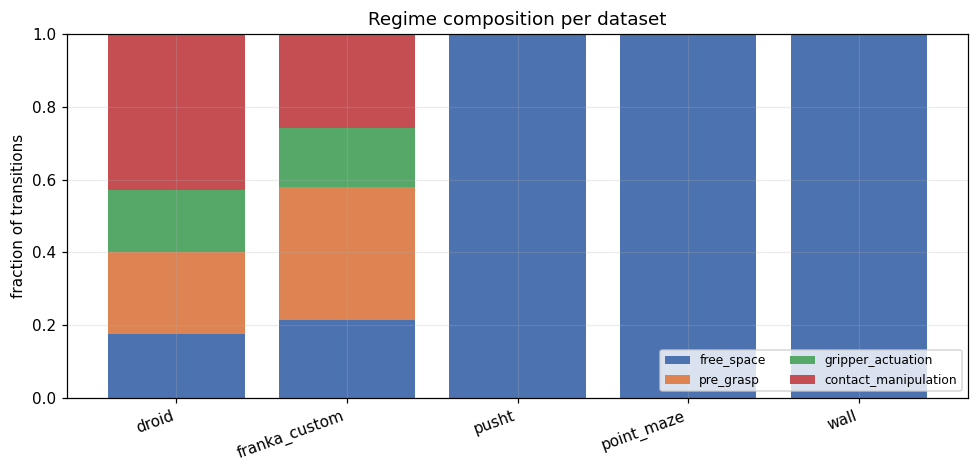

In [ ]:
present = [d for d in DATASETS if regime_counts(d, DATASETS[d][0]) is not None]
tbl = pd.DataFrame({d: regime_counts(d, DATASETS[d][0]) for d in present}).T[REGIMES]
display(tbl.assign(total=tbl.sum(1)))

frac = tbl.div(tbl.sum(1), axis=0).fillna(0)
fig, ax = plt.subplots(figsize=(9, 4.4))
bottom = np.zeros(len(frac))
for rg in REGIMES:
    ax.bar(frac.index, frac[rg], bottom=bottom, color=REGIME_COLORS[rg], label=rg)
    bottom += frac[rg].values
ax.set_ylabel("fraction of transitions"); ax.set_ylim(0, 1)
ax.set_title("Regime composition per dataset")
ax.set_xticklabels(frac.index, rotation=20, ha="right")
ax.legend(fontsize=8, ncol=2, loc="lower right"); plt.tight_layout(); plt.show()

## P3.2 · `franka_custom` — gripper-primary regimes (cross-embodiment)

A second real robot (a different Franka teleop set). It is **small** (16 clips,
~112 transitions — below `min_transitions_per_cell`, so it yields no CRA verdict)
but it does exercise the *same* gripper-primary stratifier as DROID, so the
regime structure transfers: `gripper_actuation` owns the large-|Δgrip| tail, and
the gripper-closed line splits `contact` from the open-gripper regimes.

,n
regime,
free_space,24
pre_grasp,41
gripper_actuation,18
contact_manipulation,29


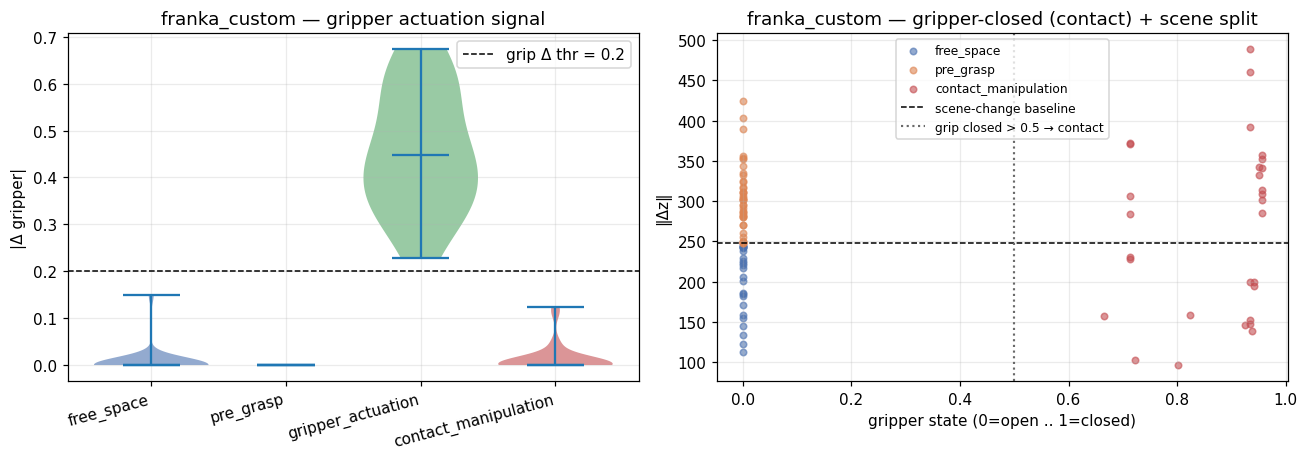

In [ ]:
FR_CACHE = PL / "franka_custom__dino_wm_droid.h5"
if FR_CACHE.exists():
    sc = json.load(open(str(FR_CACHE) + ".regimes.json"))
    fr = {k: np.asarray(v, np.int8) for k, v in sc.items()}
    rows = []
    with h5py.File(FR_CACHE, "r") as h:
        grp = h["trajectories"]
        for key in grp.keys():
            g = grp[key]; tid = g.attrs.get("traj_id", key)
            z = g["z"][:]; zf = z.reshape(z.shape[0], -1)
            grip = g["gripper"][:] if "gripper" in g else g["state"][:, 6]
            reg = fr.get(tid)
            if reg is None: continue
            for t in range(len(reg)):
                rows.append(dict(regime=ID_TO_REGIME[int(reg[t])], grip=float(grip[t]),
                                 grip_delta=float(abs(grip[t + 1] - grip[t])),
                                 dz=float(np.linalg.norm(zf[t + 1] - zf[t]))))
    fdf = pd.DataFrame(rows)
    FBASE = float(fdf.dz.median())
    display(fdf.regime.value_counts().reindex(REGIMES).fillna(0).astype(int).to_frame("n"))

    from stratification.droid_regimes import (
        GRIPPER_DELTA_THRESHOLD, GRIPPER_CLOSED_THRESHOLD, SCENE_CHANGE_RATIO)
    pres = [r for r in REGIMES if (fdf.regime == r).any()]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.3))
    data = [fdf.loc[fdf.regime == r, "grip_delta"].values for r in pres]
    parts = a1.violinplot(data, showmedians=True, widths=0.85)
    for pc, r in zip(parts["bodies"], pres): pc.set_facecolor(REGIME_COLORS[r]); pc.set_alpha(0.6)
    a1.axhline(GRIPPER_DELTA_THRESHOLD, color="k", ls="--", lw=1, label=f"grip Δ thr = {GRIPPER_DELTA_THRESHOLD}")
    a1.set_xticks(range(1, len(pres) + 1)); a1.set_xticklabels(pres, rotation=15, ha="right")
    a1.set_ylabel("|Δ gripper|"); a1.set_title("franka_custom — gripper actuation signal"); a1.legend()
    for r in pres:
        if r == "gripper_actuation": continue
        ss = fdf[fdf.regime == r]
        a2.scatter(ss.grip, ss.dz, s=18, alpha=0.6, color=REGIME_COLORS[r], label=r)
    a2.axhline(SCENE_CHANGE_RATIO * FBASE, color="k", ls="--", lw=1, label="scene-change baseline")
    a2.axvline(GRIPPER_CLOSED_THRESHOLD, color="dimgray", ls=":", lw=1.4,
               label=f"grip closed > {GRIPPER_CLOSED_THRESHOLD} → contact")
    a2.set_xlabel("gripper state (0=open .. 1=closed)"); a2.set_ylabel("‖Δz‖")
    a2.set_title("franka_custom — gripper-closed (contact) + scene split"); a2.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("franka_custom cache missing")

## P3.3 · Latent change ‖Δz‖ per dataset

The diagnostic's effect threshold is τ = median ‖Δz‖ *within each dataset*. This
shows the ‖Δz‖ scale differs by encoder/dataset (so τ is dataset-relative), and
that the toy tasks have plenty of effectful (Δz > τ) transitions — the substrate
for their high CRA below.

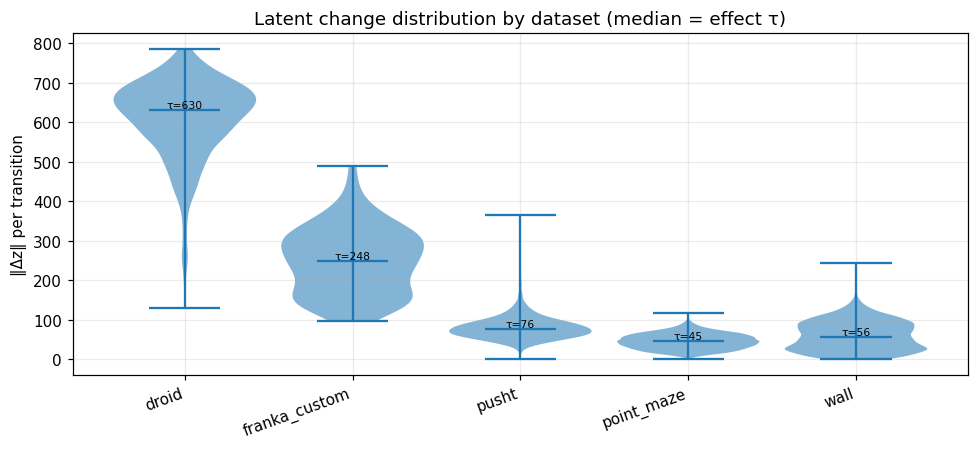

,% effectful (Δz>τ)
droid,50.0
franka_custom,50.0
pusht,50.0
point_maze,50.0
wall,50.0


In [ ]:
def dz_sample(dataset, model, cap_traj=120):
    cache = PL / f"{dataset}__{model}.h5"
    if not cache.exists(): return None
    vals = []
    with h5py.File(cache, "r") as h:
        grp = h["trajectories"]
        for i, key in enumerate(grp.keys()):
            if i >= cap_traj: break
            z = grp[key]["z"][:]; zf = z.reshape(z.shape[0], -1)
            vals.append(np.linalg.norm(np.diff(zf, axis=0), axis=1))
    return np.concatenate(vals) if vals else None

dz = {d: dz_sample(d, DATASETS[d][0]) for d in DATASETS}
dz = {d: v for d, v in dz.items() if v is not None and len(v)}
fig, ax = plt.subplots(figsize=(9, 4.2))
labels = list(dz.keys())
parts = ax.violinplot([dz[d] for d in labels], showmedians=True, widths=0.85)
for pc in parts["bodies"]: pc.set_alpha(0.55)
for i, d in enumerate(labels, 1):
    ax.text(i, np.median(dz[d]), f"τ={np.median(dz[d]):.0f}", fontsize=7, ha="center", va="bottom")
ax.set_xticks(range(1, len(labels) + 1)); ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("‖Δz‖ per transition"); ax.set_title("Latent change distribution by dataset (median = effect τ)")
plt.tight_layout(); plt.show()
display(pd.Series({d: float(np.mean(v > np.median(v)) * 100) for d, v in dz.items()},
                 name="% effectful (Δz>τ)").round(1).to_frame())

## P3.4 · DROID encoder-scaling curve — action-grounding does **not** scale

The headline diagnostic result, now a **4-point curve** over a 45× encoder
scale-up and two encoder families:

| model | encoder | params |
| --- | --- | --- |
| `dino_wm_droid` | DINOv2 ViT-S/14 | ~22M |
| `jepa_wm_droid` | DINOv3 ViT-L/16 | ~300M |
| `vjepa2_ac_droid` | V-JEPA-2 ViT-G/16 | ~1.0B |
| `vjepa2_ac_oss` | V-JEPA-2 ViT-G/16 (OSS) | ~1.0B |

Left: deterministic **`hard_nn` effect-conditioned CRA** per action-critical
regime — every model sits at the 16-way chance floor (0.0625). Right:
**`bb_boundary`** per regime — every model is boundary-blind (BB > 0), pre-grasp
the locus. Scaling the encoder does not close the gap.

*(We lead with `hard_nn`: it is deterministic, while `random`/`opposite` negatives
are unseeded and drift run-to-run.)*

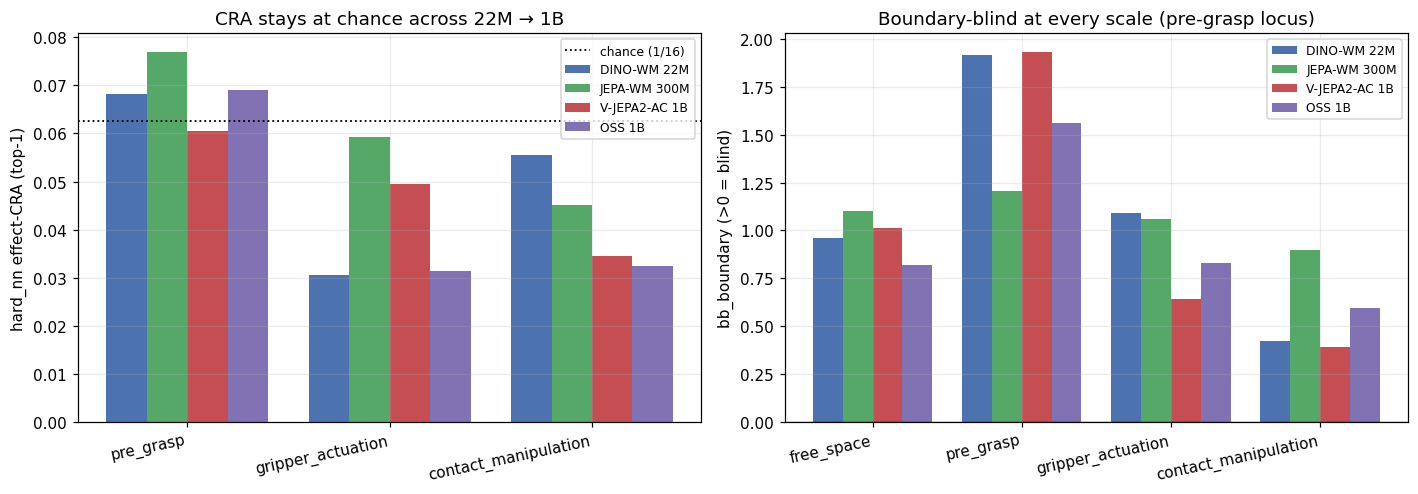

,pre_grasp,gripper_actuation,contact_manipulation
hard_nn effect-CRA,,,
DINO-WM 22M,0.068,0.031,0.055
JEPA-WM 300M,0.077,0.059,0.045
V-JEPA2-AC 1B,0.061,0.049,0.035
OSS 1B,0.069,0.031,0.033


In [ ]:
SCALE = [("dino_wm_droid", "DINO-WM 22M"), ("jepa_wm_droid", "JEPA-WM 300M"),
         ("vjepa2_ac_droid", "V-JEPA2-AC 1B"), ("vjepa2_ac_oss", "OSS 1B")]
MCOLORS = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"]
ACT_REGIMES = ["pre_grasp", "gripper_actuation", "contact_manipulation"]

dc = pd.read_csv(RESULTS / "droid_diagnostic.csv")
hn = dc[(dc.strategy == "hard_nn") & (dc.status == "ok")]
def eff(model, rg):
    r = hn[(hn.model == model) & (hn.regime == rg)]
    return float(r["cra_top1_eff"].iloc[0]) if len(r) else np.nan

bb = pd.read_csv(RESULTS / "droid_boundary.csv")
bb = bb[bb.status == "ok"]
def bbq(model, rg):
    r = bb[(bb.model == model) & (bb.regime == rg)]
    return float(r["bb_boundary"].iloc[0]) if len(r) else np.nan

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
x = np.arange(len(ACT_REGIMES)); w = 0.8 / len(SCALE)
for i, (m, lbl) in enumerate(SCALE):
    a1.bar(x + i * w, [eff(m, rg) for rg in ACT_REGIMES], w, label=lbl, color=MCOLORS[i])
a1.axhline(1 / 16, color="k", ls=":", lw=1.2, label="chance (1/16)")
a1.set_xticks(x + w * (len(SCALE) - 1) / 2); a1.set_xticklabels(ACT_REGIMES, rotation=12, ha="right")
a1.set_ylabel("hard_nn effect-CRA (top-1)"); a1.set_title("CRA stays at chance across 22M → 1B")
a1.legend(fontsize=8)

allr = REGIMES
for i, (m, lbl) in enumerate(SCALE):
    a2.bar(np.arange(len(allr)) + i * w, [bbq(m, rg) for rg in allr], w, label=lbl, color=MCOLORS[i])
a2.axhline(0, color="k", lw=0.8)
a2.set_xticks(np.arange(len(allr)) + w * (len(SCALE) - 1) / 2); a2.set_xticklabels(allr, rotation=12, ha="right")
a2.set_ylabel("bb_boundary (>0 = blind)"); a2.set_title("Boundary-blind at every scale (pre-grasp locus)")
a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

display(pd.DataFrame({lbl: [eff(m, rg) for rg in ACT_REGIMES] for m, lbl in SCALE},
                     index=ACT_REGIMES).round(3).T.rename_axis("hard_nn effect-CRA"))

## P3.5 · Positive control — the metric returns **high** when actions matter

Across datasets, effect-conditioned CRA (`opposite` and the hard `hard_nn`) for
the primary model. The **toy free-space** tasks score near-ceiling (the world
models *do* encode the action when dynamics are simple and action-driven) — which
is exactly why the near-chance scores on DROID/Metaworld contact regimes are a
real action-grounding failure, not a broken metric. `franka_custom`/`robocasa`
are `insufficient_data` (too few transitions) and omitted.

,opposite,hard_nn,status
dataset,,,
metaworld,0.979,0.515,ok
droid,NaN,NaN,ok
franka_custom,NaN,NaN,insufficient
pusht,1.000,0.698,ok
point_maze,0.976,0.851,ok
wall,1.000,0.899,ok


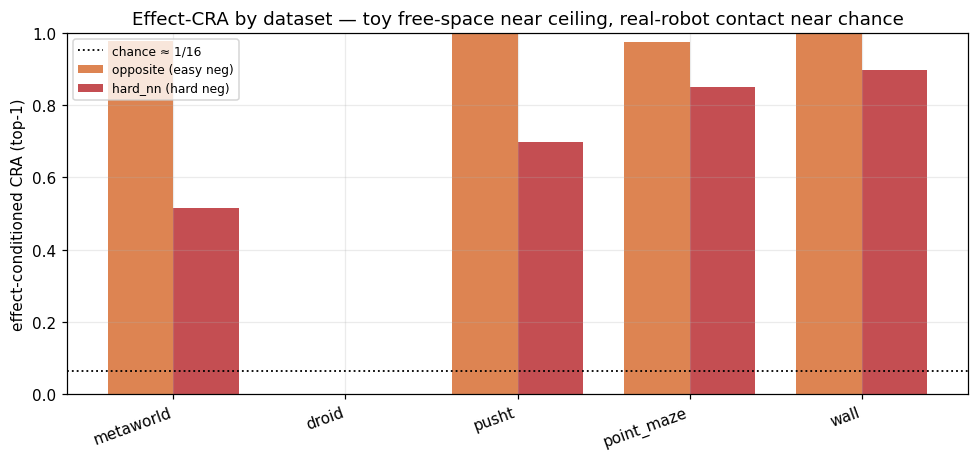

In [ ]:
def wmean(g):
    w = g["n_effect"].clip(lower=1) if "n_effect" in g else np.ones(len(g))
    return np.average(g["cra_top1_eff"], weights=w)

rows = []
for ds, (_, csv, model) in DATASETS.items():
    p = RESULTS / csv
    if not p.exists(): continue
    t = pd.read_csv(p)
    if "cra_top1_eff" not in t.columns:
        rows.append((ds, np.nan, np.nan, "insufficient")); continue
    t = t[(t.model == model) & (t.status == "ok")]
    if not len(t): rows.append((ds, np.nan, np.nan, "insufficient")); continue
    opp = t[t.strategy == "opposite"]; hn = t[t.strategy == "hard_nn"]
    rows.append((ds, wmean(opp) if len(opp) else np.nan,
                 wmean(hn) if len(hn) else np.nan, "ok"))
summ = pd.DataFrame(rows, columns=["dataset", "opposite", "hard_nn", "status"]).set_index("dataset")
display(summ.round(3))

ok = summ[summ.status == "ok"]
fig, ax = plt.subplots(figsize=(9, 4.3))
x = np.arange(len(ok)); w = 0.38
ax.bar(x - w/2, ok["opposite"].values, w, label="opposite (easy neg)", color="#DD8452")
ax.bar(x + w/2, ok["hard_nn"].values, w, label="hard_nn (hard neg)", color="#C44E52")
ax.axhline(1 / 16, color="k", ls=":", lw=1.2, label="chance ≈ 1/16")
ax.set_xticks(x); ax.set_xticklabels(ok.index, rotation=20, ha="right")
ax.set_ylabel("effect-conditioned CRA (top-1)"); ax.set_ylim(0, 1)
ax.set_title("Effect-CRA by dataset — toy free-space near ceiling, real-robot contact near chance")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## P3.6 · Part 3 sanity checks

In [ ]:
checks = []
toy_counts = {d: regime_counts(d, DATASETS[d][0]) for d in ["pusht", "point_maze", "wall"]}
checks.append(("toy datasets are free_space-only",
               all(c is not None and c.drop("free_space").sum() == 0 for c in toy_counts.values())))
dr = regime_counts("droid", "dino_wm_droid")
checks.append(("DROID populates all four regimes", dr is not None and (dr > 0).all()))
fr = regime_counts("franka_custom", "dino_wm_droid")
checks.append(("franka_custom populates all four regimes", fr is not None and (fr > 0).all()))
dc = pd.read_csv(RESULTS / "droid_diagnostic.csv")
checks.append(("DROID CSV has all 4 scaling models",
               set(["dino_wm_droid","jepa_wm_droid","vjepa2_ac_droid","vjepa2_ac_oss"]).issubset(set(dc.model))))
hn = dc[(dc.strategy == "hard_nn") & (dc.status == "ok") & (dc.regime != "free_space")]
checks.append(("all 4 models ≤ 0.12 hard_nn effect-CRA in action regimes",
               (hn.groupby("model")["cra_top1_eff"].max() <= 0.12).all()))
for name, ok in checks:
    print(("PASS" if ok else "FAIL"), "-", name)
print(f"\n{sum(o for _, o in checks)}/{len(checks)} Part-3 checks passed")

PASS - toy datasets are free_space-only
PASS - DROID populates all four regimes
PASS - franka_custom populates all four regimes
PASS - DROID CSV has all 4 scaling models
PASS - all 4 models ≤ 0.12 hard_nn effect-CRA in action regimes

5/5 Part-3 checks passed
